# Etapa 1 — Análisis exploratorio, preprocesamiento y detección de *data leakage*

**Tarea 2 · Proyecto integrador de Aprendizaje Automático (sección 10.12) · Notebook 1 de 2** (`notebooks/1_model_leakage_demo.ipynb`)

| | |
|---|---|
| **Integrantes** | Martínez Pulido Valerie · Basto Martínez Abrahan · Esguerra Fernández Rubén |
| **Curso** | Machine Learning — Dr. Lihki Rubio |
| **Dataset** | [Heart Failure Prediction](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction) (Kaggle, fedesoriano): 918 pacientes, 11 variables clínicas y la variable objetivo `HeartDisease` (1 = enfermedad cardíaca, 0 = no) |
| **Repositorio** | https://github.com/RubenEsg/Machine-Learning-Tarea-2 |
| **Jupyter Book** | https://rubenesg.github.io/Machine-Learning-Tarea-2/ |

Este notebook es **autocontenido**: se puede ejecutar de principio a fin dentro del repositorio o por separado, en otro computador. Si no encuentra `data/heart.csv`, descarga el dataset desde el repositorio (o, si no está disponible, directamente desde Kaggle) y verifica su huella SHA-256; si falta alguna librería, la instala.

**Requisitos del enunciado para esta etapa y dónde se cubren**

| Requisito | Sección |
|---|---|
| Explorar el dataset, tratar valores nulos y preparar los datos | 2 a 5 |
| Evitar *data leakage*: ejemplo de flujo con y sin fuga | 3 y 6 |
| Implementar todos los modelos vistos (al menos 3 además de SVC), cada uno en un `Pipeline` con `GridSearchCV` | 7 |
| Comparar AUC y *accuracy* y presentar un ranking comparativo | 8 |
| Separar el código en funciones reutilizables | 1.2 |

El entrenamiento del modelo final, su evaluación, la exportación para la API y el monitoreo están en el notebook 2 (`2_model_pipeline_cv.ipynb`).

**Reglas que guían todo el trabajo:** la partición entrenamiento/prueba se hace **antes** de cualquier transformación que aprenda de los datos, y el conjunto de prueba **nunca se usa para decidir** (preprocesamiento, modelo, hiperparámetros o umbral): solo sirve para reportar el desempeño con pacientes que el modelo no vio.

## 1. Configuración

### 1.1 Dependencias, rutas y datos

Probado con Python 3.13, scikit-learn 1.7.2, numpy 2.2.6 y pandas 2.3.3, las mismas versiones de la imagen Docker de la API. Con otras versiones los resultados pueden variar en los últimos decimales.

In [1]:
import importlib.util
import subprocess
import sys

# Si falta alguna librería, se instala.
DEPENDENCIAS = {"numpy": "numpy", "pandas": "pandas", "scipy": "scipy", "sklearn": "scikit-learn",
                "matplotlib": "matplotlib", "joblib": "joblib", "xgboost": "xgboost"}
faltantes = [paquete for modulo, paquete in DEPENDENCIAS.items() if importlib.util.find_spec(modulo) is None]
if faltantes:
    print("Instalando dependencias faltantes:", ", ".join(faltantes))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *faltantes])
else:
    print("Todas las dependencias están instaladas.")

Todas las dependencias están instaladas.


In [2]:
import hashlib
import io
import json
import platform
import time
import urllib.request
import zipfile
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (AdaBoostClassifier, BaggingClassifier, GradientBoostingClassifier,
                              RandomForestClassifier)
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import (GridSearchCV, KFold, StratifiedKFold, cross_val_predict,
                                     cross_val_score, cross_validate, learning_curve, train_test_split)
from sklearn.naive_bayes import BernoulliNB, GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Rutas: dentro del repositorio el notebook está en notebooks/, así que la raíz es la carpeta
# padre; si se ejecuta por separado, los archivos se guardan en la carpeta actual.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPO_URL = "https://github.com/RubenEsg/Machine-Learning-Tarea-2"
DATA_URL = "https://raw.githubusercontent.com/RubenEsg/Machine-Learning-Tarea-2/main/data/heart.csv"
KAGGLE_URL = "https://www.kaggle.com/api/v1/datasets/download/fedesoriano/heart-failure-prediction"
DATA_SHA256 = "948420b084d8a3a0ca42b8419fce9aee175879e43f8aedf712377899a67aa49b"  # CSV original de Kaggle
DATA_PATH = PROJECT_ROOT / "data" / "heart.csv"
APP_DIR = PROJECT_ROOT / "app"
MODEL_PATH = APP_DIR / "model.joblib"           # lo carga la API y lo copia el Dockerfile
ROOT_MODEL_PATH = PROJECT_ROOT / "model.joblib"  # copia según la estructura de la Etapa 0
METADATA_PATH = APP_DIR / "model_metadata.json"
DRIFT_REPORT_PATH = PROJECT_ROOT / "drift_report.html"
MONITORING_DIR = PROJECT_ROOT / "monitoring"

pd.set_option("display.precision", 4)
pd.set_option("display.max_colwidth", 100)
print("Python", platform.python_version(), "| scikit-learn", sklearn.__version__,
      "| pandas", pd.__version__, "| numpy", np.__version__)

Python 3.13.3 | scikit-learn 1.7.2 | pandas 2.3.3 | numpy 2.2.6


### 1.2 Funciones reutilizables

El enunciado pide separar el código en funciones reutilizables. Todas se definen aquí y se usan en el resto del notebook; los mismos criterios (columnas, semilla y partición) se usan en las pruebas automáticas y en el script de monitoreo del repositorio.

**a) Configuración y datos.** La partición se hace sobre los datos crudos, antes de cualquier transformación que aprenda de ellos.

In [3]:
TARGET = "HeartDisease"
# Orden original de las columnas del CSV (sin la variable objetivo).
FEATURES = ["Age", "Sex", "ChestPainType", "RestingBP", "Cholesterol", "FastingBS",
            "RestingECG", "MaxHR", "ExerciseAngina", "Oldpeak", "ST_Slope"]
NUMERIC_FEATURES = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]
CATEGORICAL_FEATURES = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
# Un 0 en estas columnas es fisiológicamente imposible: es un valor "no medido".
ZERO_AS_MISSING = ["RestingBP", "Cholesterol"]
EXPECTED_CATEGORIES = {"Sex": {"M", "F"}, "ChestPainType": {"TA", "ATA", "NAP", "ASY"},
                       "RestingECG": {"Normal", "ST", "LVH"}, "ExerciseAngina": {"Y", "N"},
                       "ST_Slope": {"Up", "Flat", "Down"}}
RANDOM_STATE = 42  # semilla de la partición, de los folds y de los modelos
TEST_SIZE = 0.2    # 80 % entrenamiento / 20 % prueba
CV_FOLDS = 5


def validate_schema(df):
    # Verifica columnas, variable objetivo binaria y categorías conocidas.
    missing = set(FEATURES + [TARGET]) - set(df.columns)
    if missing:
        raise ValueError(f"Faltan columnas en el dataset: {sorted(missing)}")
    if not set(df[TARGET].unique()) <= {0, 1}:
        raise ValueError(f"{TARGET} debe ser binaria (0/1)")
    for col in CATEGORICAL_FEATURES:
        unknown = set(df[col].unique()) - EXPECTED_CATEGORIES[col]
        if unknown:
            raise ValueError(f"Categorías inesperadas en {col}: {unknown}")


def download_dataset(path):
    # Descarga el CSV desde el repositorio; si no está disponible, desde la API pública de Kaggle.
    try:
        print(f"Descargando el dataset desde {DATA_URL}")
        urllib.request.urlretrieve(DATA_URL, path)
    except OSError as exc:
        print(f"No se pudo descargar desde el repositorio ({exc}); se descarga desde Kaggle.")
        with urllib.request.urlopen(KAGGLE_URL, timeout=60) as respuesta:
            path.write_bytes(zipfile.ZipFile(io.BytesIO(respuesta.read())).read("heart.csv"))


def load_data(path=DATA_PATH):
    # Lee data/heart.csv; si no existe (notebook fuera del repositorio), lo descarga.
    path = Path(path)
    if not path.exists():
        path.parent.mkdir(parents=True, exist_ok=True)
        download_dataset(path)
    huella = hashlib.sha256(path.read_bytes()).hexdigest()
    if huella != DATA_SHA256:
        raise ValueError(f"El archivo {path} no es el CSV original de Kaggle (SHA-256 {huella[:12]}...)")
    df = pd.read_csv(path)
    validate_schema(df)
    return df


def split_data(df, test_size=TEST_SIZE, random_state=RANDOM_STATE):
    # Partición estratificada train/test sobre los datos crudos: X_train, X_test, y_train, y_test.
    return train_test_split(df[FEATURES], df[TARGET], test_size=test_size,
                            stratify=df[TARGET], random_state=random_state)


def split_fingerprint(X_test):
    # Huella corta de los índices de prueba: permite verificar que otro proceso usa la misma partición.
    ids = ",".join(str(i) for i in sorted(X_test.index))
    return hashlib.sha256(ids.encode()).hexdigest()[:12]

**b) Preprocesamiento, Pipeline y catálogo de modelos.** `train_pipeline` generaliza la función que sugiere el enunciado: el Pipeline es `preprocessor → scaler → clf`, y todas sus etapas se ajustan solo con los datos de entrenamiento de cada fold.

In [4]:
SCORING = {"roc_auc": "roc_auc", "accuracy": "accuracy"}


def get_cv(n_splits=CV_FOLDS, random_state=RANDOM_STATE):
    # Validación cruzada estratificada CON barajado (el CSV está ordenado por hospital, sección 3.1).
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)


def build_preprocessor(add_indicator=False):
    # Imputa los ceros de RestingBP/Cholesterol con la mediana y codifica las categóricas.
    other_numeric = [c for c in NUMERIC_FEATURES if c not in ZERO_AS_MISSING]
    return ColumnTransformer([
        ("imputer", SimpleImputer(missing_values=0, strategy="median", add_indicator=add_indicator),
         ZERO_AS_MISSING),
        ("numeric", "passthrough", other_numeric),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
    ])


def build_pipeline(model, scaler=None, add_indicator=False):
    # Pipeline completo: preprocesamiento -> escalado (MinMaxScaler por defecto) -> clasificador.
    return Pipeline([
        ("preprocessor", build_preprocessor(add_indicator=add_indicator)),
        ("scaler", MinMaxScaler() if scaler is None else scaler),
        ("clf", model),
    ])


def train_pipeline(X_train, y_train, model, param_grid, cv=None, scoring=SCORING, refit="roc_auc", n_jobs=-1):
    # GridSearchCV solo con X_train; registra AUC y accuracy y elige por AUC (refit).
    grid = GridSearchCV(build_pipeline(model), param_grid, cv=get_cv() if cv is None else cv,
                        scoring=scoring, refit=refit, n_jobs=n_jobs, return_train_score=True)
    grid.fit(X_train, y_train)
    return grid


def get_model_catalog(random_state=RANDOM_STATE):
    # Clasificadores vistos en el curso con su grilla (prefijo 'clf__' = paso del Pipeline).
    return {
        "k-NN": dict(capitulo="2. k-NN", model=KNeighborsClassifier(),
                     param_grid={"clf__n_neighbors": [5, 11, 21, 31, 51, 71, 101, 151, 201],
                                 "clf__weights": ["uniform", "distance"], "clf__p": [1, 2]}),
        "Regresión logística": dict(capitulo="3. Modelos lineales", model=LogisticRegression(max_iter=5000),
                                    param_grid={"clf__C": [0.001, 0.01, 0.1, 1, 10, 100]}),
        "LinearSVC": dict(capitulo="3. Modelos lineales",
                          model=LinearSVC(max_iter=20000, random_state=random_state),
                          param_grid={"clf__C": [0.001, 0.01, 0.1, 1, 10]}),
        "Naive Bayes gaussiano": dict(capitulo="4. Clasificador bayesiano", model=GaussianNB(),
                                      param_grid={"clf__var_smoothing": np.logspace(-9, 1, 11)}),
        # Tras el MinMaxScaler todo queda en [0, 1]; binarize fija desde qué valor una variable cuenta como 1.
        "Naive Bayes Bernoulli": dict(capitulo="4. Clasificador bayesiano", model=BernoulliNB(),
                                      param_grid={"clf__alpha": [0.1, 1, 10, 30, 100],
                                                  "clf__binarize": [0.25, 0.5, 0.75]}),
        "Árbol de decisión": dict(capitulo="5. Árboles", model=DecisionTreeClassifier(random_state=random_state),
                                  param_grid={"clf__max_depth": [2, 3, 4, 5, 6, 8, None],
                                              "clf__min_samples_leaf": [1, 5, 10, 20, 30, 50],
                                              "clf__criterion": ["gini", "entropy"]}),
        "Bagging (árboles)": dict(capitulo="5. Bagging",
                                  model=BaggingClassifier(DecisionTreeClassifier(), n_estimators=200,
                                                          random_state=random_state),
                                  param_grid={"clf__max_samples": [0.1, 0.25, 0.5, 0.75, 1.0],
                                              "clf__max_features": [0.1, 0.25, 0.5, 0.75, 1.0]}),
        "Random Forest": dict(capitulo="5. Random Forest",
                              model=RandomForestClassifier(n_estimators=300, random_state=random_state),
                              param_grid={"clf__max_depth": [4, 6, 8, None], "clf__max_features": ["sqrt", 0.5],
                                          "clf__min_samples_leaf": [1, 3, 5]}),
        "AdaBoost": dict(capitulo="5. Boosting (AdaBoost)", model=AdaBoostClassifier(random_state=random_state),
                         param_grid={"clf__n_estimators": [50, 100, 200, 400],
                                     "clf__learning_rate": [0.01, 0.03, 0.1, 0.3, 1.0]}),
        "Gradient Boosting": dict(capitulo="5. Boosting",
                                  model=GradientBoostingClassifier(random_state=random_state),
                                  param_grid={"clf__n_estimators": [100, 300, 600],
                                              "clf__learning_rate": [0.003, 0.01, 0.03, 0.1],
                                              "clf__max_depth": [2, 3, 4], "clf__subsample": [0.4, 0.6, 0.8, 1.0]}),
        "XGBoost": dict(capitulo="5. XGBoost",
                        model=XGBClassifier(eval_metric="logloss", n_jobs=1, random_state=random_state),
                        param_grid={"clf__n_estimators": [100, 300, 600, 1000],
                                    "clf__learning_rate": [0.003, 0.01, 0.03, 0.1],
                                    "clf__max_depth": [2, 3, 4], "clf__subsample": [0.4, 0.6, 0.8, 1.0]}),
        "SVC (RBF)": dict(capitulo="6. SVM", model=SVC(probability=True, random_state=random_state),
                          param_grid={"clf__C": [0.01, 0.1, 1, 10, 100], "clf__gamma": [0.001, 0.01, 0.1, 1]}),
        "MLP": dict(capitulo="9. Evaluación (ej. DeLong)", model=MLPClassifier(max_iter=3000, random_state=random_state),
                    param_grid={"clf__hidden_layer_sizes": [(16,), (32,), (32, 16)],
                                "clf__alpha": [0.01, 0.1, 1.0, 10.0]}),
        "Dummy (línea base)": dict(capitulo="9. Evaluación", model=DummyClassifier(strategy="prior"),
                                   param_grid={}),
    }

**c) Evaluación, ranking y pruebas estadísticas.** Incluye el test de DeLong pareado para comparar AUC (cap. 9.9) y el intervalo de confianza bootstrap.

In [5]:
def positive_scores(estimator, X):
    # Puntaje de la clase positiva: predict_proba si existe; si no (LinearSVC), decision_function.
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    return estimator.decision_function(X)


def classification_metrics(y_true, y_pred, scores):
    # AUC, accuracy, precisión, sensibilidad, especificidad y F1.
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {"auc": roc_auc_score(y_true, scores), "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "specificity": tn / (tn + fp), "f1": f1_score(y_true, y_pred, zero_division=0)}


def evaluate_on_test(estimator, X_test, y_test):
    # Métricas en el conjunto de prueba (solo para reportar).
    metrics = classification_metrics(y_test, estimator.predict(X_test), positive_scores(estimator, X_test))
    return {f"test_{k}": v for k, v in metrics.items()}


def summarize_search(grid):
    # Resultados de validación cruzada de la mejor configuración.
    cv, i = grid.cv_results_, grid.best_index_
    return {"cv_auc": cv["mean_test_roc_auc"][i], "cv_auc_std": cv["std_test_roc_auc"][i],
            "cv_accuracy": cv["mean_test_accuracy"][i], "cv_accuracy_std": cv["std_test_accuracy"][i],
            "train_auc": cv["mean_train_roc_auc"][i],
            "gap_auc": cv["mean_train_roc_auc"][i] - cv["mean_test_roc_auc"][i],
            "n_combinaciones": len(cv["params"]),
            "mejores_parametros": {k.replace("clf__", ""): v for k, v in grid.best_params_.items()}}


# "p" elige la métrica de distancia de k-NN (no es ordinal) y las fracciones tienen máximo natural 1.0.
NON_ORDINAL_PARAMS = {"p"}
FRACTION_PARAMS = {"subsample", "max_samples", "max_features"}


def _is_number(value):
    return isinstance(value, (int, float, np.number)) and not isinstance(value, bool)


def grid_boundary_warnings(grid):
    # Hiperparámetros cuyo óptimo quedó en el borde de la grilla (conviene ampliarla, cap. 9).
    param_grid = grid.param_grid
    if isinstance(param_grid, list):  # grilla de varios modelos (cap. 10.11)
        param_grid = next(pg for pg in param_grid if set(pg) == set(grid.best_params_))
    avisos = []
    for name, values in param_grid.items():
        short, values = name.replace("clf__", ""), list(values)
        nums = [v for v in values if _is_number(v)]
        best = grid.best_params_[name]
        if short in NON_ORDINAL_PARAMS or len(nums) < 2 or not _is_number(best):
            continue
        natural_upper = None in values or (short in FRACTION_PARAMS and max(nums) == 1.0)
        if best == min(nums) or (best == max(nums) and not natural_upper):
            avisos.append(f"{short}={best} (grilla: {min(nums)} a {max(nums)})")
    return avisos


def compare_models(catalog, X_train, y_train, X_test, y_test, cv=None, verbose=True):
    # Pipeline + GridSearchCV por modelo; métricas de CV (selección) y de prueba (reporte).
    rows, fitted = [], {}
    for name, spec in catalog.items():
        start = time.perf_counter()
        grid = train_pipeline(X_train, y_train, spec["model"], spec["param_grid"], cv=cv)
        row = {"modelo": name, "capitulo": spec["capitulo"], **summarize_search(grid),
               **evaluate_on_test(grid, X_test, y_test),
               "avisos_borde": "; ".join(grid_boundary_warnings(grid)),
               "tiempo_s": time.perf_counter() - start}
        rows.append(row)
        fitted[name] = grid
        if verbose:
            print(f"{name:<24} CV AUC = {row['cv_auc']:.3f} (± {row['cv_auc_std']:.3f}) | {row['tiempo_s']:5.1f} s")
    return pd.DataFrame(rows).set_index("modelo"), fitted


def rank_models(results, by="cv_auc"):
    # Ranking de SELECCIÓN por AUC de validación cruzada (el conjunto de prueba no participa).
    ranked = results.sort_values([by, "cv_accuracy"], ascending=False).copy()
    ranked.insert(0, "ranking", np.arange(1, len(ranked) + 1))
    return ranked


def _placements(pos_scores, neg_scores):
    # Componentes estructurales de DeLong V10 (positivos) y V01 (negativos) con la función psi.
    diff = pos_scores[:, None] - neg_scores[None, :]
    psi = (diff > 0).astype(float) + 0.5 * (diff == 0)
    return psi.mean(axis=1), psi.mean(axis=0)


def delong_test(y_true, scores_a, scores_b):
    # Test de DeLong pareado, H0: AUC_a = AUC_b. Incluye la covarianza entre ambos AUC (cap. 9.9.1).
    y = np.asarray(y_true)
    a, b = np.asarray(scores_a, dtype=float), np.asarray(scores_b, dtype=float)
    pos, neg = y == 1, y == 0
    m, n = pos.sum(), neg.sum()
    v10_a, v01_a = _placements(a[pos], a[neg])
    v10_b, v01_b = _placements(b[pos], b[neg])
    s = np.cov(np.vstack([v10_a, v10_b])) / m + np.cov(np.vstack([v01_a, v01_b])) / n  # ddof = 1
    var_diff = s[0, 0] + s[1, 1] - 2 * s[0, 1]
    delta = v10_a.mean() - v10_b.mean()
    if var_diff <= 0:
        z, p_value = 0.0, 1.0
    else:
        z = delta / np.sqrt(var_diff)
        p_value = 2 * stats.norm.sf(abs(z))
    return {"auc_a": v10_a.mean(), "auc_b": v10_b.mean(), "delta_auc": delta, "z": z, "p_value": p_value}


def auc_difference_magnitude(delta):
    # Leyenda del cap. 9.9.1: < 0.01 trivial, 0.01-0.03 pequeña, 0.03-0.05 moderada, > 0.05 importante.
    d = abs(delta)
    return "trivial" if d < 0.01 else "pequeña" if d < 0.03 else "moderada" if d <= 0.05 else "importante"


def interpret_difference(delta, p_value, alpha=0.05):
    large, significant = abs(delta) >= 0.03, p_value < alpha
    if large and significant:
        return "Diferencia significativa y relevante"
    if large:
        return "Diferencia aparente, no estadísticamente significativa"
    if significant:
        return "Diferencia significativa pero de bajo impacto"
    return "Diferencia trivial y no significativa"


def delong_vs_reference(y_true, scores_by_model, reference, alpha=0.05):
    # Compara el modelo de referencia contra cada uno de los demás con DeLong.
    rows = []
    for name, scores in scores_by_model.items():
        if name == reference:
            continue
        res = delong_test(y_true, scores_by_model[reference], scores)
        rows.append({"comparacion": f"{reference} vs {name}", "delta_auc": res["delta_auc"],
                     "magnitud": auc_difference_magnitude(res["delta_auc"]), "z": res["z"],
                     "p_value": res["p_value"], "significativa": "Sí" if res["p_value"] < alpha else "No",
                     "interpretacion": interpret_difference(res["delta_auc"], res["p_value"], alpha)})
    return pd.DataFrame(rows).set_index("comparacion")


def bootstrap_auc_ci(y_true, scores, n_boot=2000, alpha=0.05, random_state=RANDOM_STATE):
    # Intervalo de confianza bootstrap (percentil) para el AUC.
    rng = np.random.default_rng(random_state)
    y, s = np.asarray(y_true), np.asarray(scores)
    aucs = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y), len(y))
        if y[idx].min() != y[idx].max():  # la muestra necesita ambas clases
            aucs.append(roc_auc_score(y[idx], s[idx]))
    return tuple(np.percentile(aucs, [100 * alpha / 2, 100 * (1 - alpha / 2)]))

**e) Gráficas.** Convención de color: azul = sin enfermedad (clase 0) o serie principal; naranja = con enfermedad (clase 1) o serie de contraste; gris = referencias y modelos no resaltados.

In [6]:
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE = "#2a78d6", "#eb6834"
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
CLASS_COLORS = {0: BLUE, 1: ORANGE}
CLASS_LABELS = {0: "Sin enfermedad (0)", 1: "Con enfermedad (1)"}
BLUE_RAMP = LinearSegmentedColormap.from_list("blue_ramp", ["#cde2fb", "#86b6ef", "#3987e5", "#256abf",
                                                             "#184f95", "#0d366b"])
DIVERGING = LinearSegmentedColormap.from_list("blue_red", ["#1c5cab", "#86b6ef", "#f0efec", "#f09a99", "#c73030"])


def set_style():
    mpl.rcParams.update({
        "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE, "figure.dpi": 110,
        "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
        "axes.titlesize": 11, "axes.labelsize": 10, "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "grid.linestyle": "-",
        "axes.axisbelow": True, "axes.prop_cycle": mpl.cycler(color=CATEGORICAL),
        "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
        "lines.linewidth": 2, "lines.markersize": 7, "legend.frameon": False, "legend.fontsize": 9,
        "text.color": INK, "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    })


def _hide_unused(axes, used):
    for ax in axes.flat[used:]:
        ax.set_visible(False)


def plot_file_order(df, target, window=50):
    # Proporciones móviles siguiendo el orden del CSV (df puede ser un subconjunto: el eje x usa el índice).
    df = df.sort_index()
    pos = df.index.to_numpy()
    kw = dict(window=window, center=True, min_periods=window // 2)
    fig, ax = plt.subplots(figsize=(9.5, 3.6))
    ax.plot(pos, df[target].rolling(**kw).mean(), color=ORANGE, label="Proporción con enfermedad")
    ax.plot(pos, df["Cholesterol"].eq(0).astype(float).rolling(**kw).mean(), color=INK_2,
            label="Proporción con Cholesterol = 0")
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0, pos.max())
    ax.set_xlabel("Posición de la fila en heart.csv")
    ax.set_ylabel(f"Proporción (ventana de {window} pacientes)")
    ax.set_title("Las filas del CSV están agrupadas por hospital de origen", loc="left")
    ax.legend(loc="upper right", ncols=2)
    fig.tight_layout()
    return fig


def plot_numeric_by_class(X, y, columns, zero_as_missing=()):
    # Histogramas (densidad) por clase; en columnas donde 0 = "no medido" se excluyen los ceros.
    ncols, nrows = 3, int(np.ceil(len(columns) / 3))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.3 * nrows))
    for ax, col in zip(axes.flat, columns):
        values, labels, note = X[col], y, ""
        if col in zero_as_missing:
            keep = values != 0
            note = f" ({(~keep).sum()} ceros excluidos)"
            values, labels = values[keep], y[keep]
        bins = np.histogram_bin_edges(values, bins=25)
        for cls in (0, 1):
            ax.hist(values[labels == cls], bins=bins, density=True, histtype="step", linewidth=2,
                    color=CLASS_COLORS[cls], label=CLASS_LABELS[cls])
        ax.set_title(col + note, loc="left")
        ax.set_yticks([])
        ax.grid(False)
    _hide_unused(axes, len(columns))
    handles, labels = axes.flat[0].get_legend_handles_labels()
    if len(columns) < axes.size:  # leyenda en el primer panel vacío
        spare = axes.flat[len(columns)]
        spare.set_visible(True)
        spare.axis("off")
        spare.legend(handles, labels, loc="center", fontsize=10)
    else:
        axes.flat[0].legend(loc="upper left")
    fig.suptitle("Distribución de las variables numéricas por clase (solo entrenamiento)",
                 x=0.01, ha="left", fontsize=12)
    fig.tight_layout()
    return fig


def plot_category_rates(X, y, columns):
    # Porcentaje de pacientes con enfermedad en cada categoría.
    overall = y.mean()
    ncols, nrows = 3, int(np.ceil(len(columns) / 3))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 2.9 * nrows))
    for ax, col in zip(axes.flat, columns):
        tabla = y.groupby(X[col]).agg(["mean", "size"]).sort_values("mean")
        ypos = np.arange(len(tabla))
        ax.barh(ypos, tabla["mean"], height=0.6, color=ORANGE)
        ax.axvline(overall, color=MUTED, linewidth=1)
        for yi, (rate, n) in zip(ypos, tabla.itertuples(index=False)):
            ax.text(rate + 0.02, yi, f"{rate:.0%}  (n={n})", va="center", fontsize=8.5, color=INK_2)
        ax.set_yticks(ypos, [str(c) for c in tabla.index])
        ax.set_xlim(0, 1.25)
        ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0], ["0%", "25%", "50%", "75%", "100%"])
        ax.grid(axis="y", visible=False)
        ax.set_title(col, loc="left")
    _hide_unused(axes, len(columns))
    fig.suptitle("Porcentaje con enfermedad cardíaca por categoría (solo entrenamiento). "
                 f"Línea gris = promedio global ({overall:.0%})", x=0.01, ha="left", fontsize=12)
    fig.tight_layout()
    return fig


def correlation_with_target(X, y, columns, zero_as_missing=()):
    # Correlación de Pearson (numéricas + objetivo); los ceros "no medidos" se tratan como faltantes.
    data = X[columns].copy()
    for col in zero_as_missing:
        data[col] = data[col].replace(0, np.nan)
    data[y.name] = y
    return data.corr(method="pearson")


def plot_correlation(corr, title):
    fig, ax = plt.subplots(figsize=(6.8, 5.6))
    im = ax.imshow(corr.values, cmap=DIVERGING, vmin=-1, vmax=1)
    labels = list(corr.columns)
    ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
    ax.set_yticks(range(len(labels)), labels)
    ax.grid(False)
    for i in range(len(labels)):
        for j in range(len(labels)):
            v = corr.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color="white" if abs(v) > 0.6 else INK)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).outline.set_visible(False)
    ax.set_title(title, loc="left")
    fig.tight_layout()
    return fig


def plot_model_ranking(ranked, exclude=()):
    # AUC de validación cruzada (media ± d.e.) y AUC en prueba, ordenados por AUC de CV.
    data = ranked.drop(index=[m for m in exclude if m in ranked.index]).iloc[::-1]
    ypos = np.arange(len(data))
    fig, ax = plt.subplots(figsize=(8.5, 0.45 * len(data) + 1.8))
    cv = ax.errorbar(data["cv_auc"], ypos, xerr=data["cv_auc_std"], fmt="o", color=BLUE, ecolor=BLUE,
                     elinewidth=2, capsize=0, markersize=8)
    test = ax.scatter(data["test_auc"], ypos + 0.18, marker="D", s=40, color=ORANGE, zorder=3)
    ax.set_yticks(ypos, data.index)
    ax.grid(axis="y", visible=False)
    ax.set_xlabel("ROC-AUC")
    ax.set_title("Ranking de modelos (orden por AUC de validación cruzada)", loc="left", pad=30)
    ax.legend([cv, test], ["AUC validación cruzada (media ± 1 d.e.)", "AUC en prueba (solo reporte)"],
              loc="lower left", bbox_to_anchor=(0, 1.0), ncols=2)
    fig.tight_layout()
    return fig


def plot_roc_emphasis(y_true, scores_by_model, highlight, ax):
    # Curvas ROC: el modelo resaltado en azul y el resto en gris.
    for name, scores in scores_by_model.items():
        if name != highlight:
            fpr, tpr, _ = roc_curve(y_true, scores)
            ax.plot(fpr, tpr, color=AXIS, linewidth=1)
    ax.plot([], [], color=AXIS, linewidth=1, label="Otros modelos")
    fpr, tpr, _ = roc_curve(y_true, scores_by_model[highlight])
    ax.plot(fpr, tpr, color=BLUE, linewidth=2.5,
            label=f"{highlight} (AUC = {roc_auc_score(y_true, scores_by_model[highlight]):.3f})")
    ax.plot([0, 1], [0, 1], color=MUTED, linewidth=1, label="Azar (AUC = 0.5)")
    ax.set_xlabel("Tasa de falsos positivos (1 - especificidad)")
    ax.set_ylabel("Tasa de verdaderos positivos (sensibilidad)")
    ax.set_aspect("equal")
    ax.legend(loc="lower right")
    return ax


def plot_roc(y_true, scores, label, ax, threshold=0.5):
    # Curva ROC de un modelo con el punto de operación del umbral.
    fpr, tpr, thr = roc_curve(y_true, scores)
    ax.plot(fpr, tpr, color=BLUE, label=f"{label} (AUC = {roc_auc_score(y_true, scores):.3f})")
    ax.fill_between(fpr, tpr, color=BLUE, alpha=0.08)
    ax.plot([0, 1], [0, 1], color=MUTED, linewidth=1, label="Azar (AUC = 0.5)")
    i = np.argmin(np.abs(thr - threshold))
    ax.scatter(fpr[i], tpr[i], s=70, color=INK, zorder=3, label=f"Umbral {threshold}")
    ax.set_xlabel("Tasa de falsos positivos (1 - especificidad)")
    ax.set_ylabel("Tasa de verdaderos positivos (sensibilidad)")
    ax.set_aspect("equal")
    ax.legend(loc="lower right")
    return ax


def plot_confusion(y_true, y_pred, ax, title="Matriz de confusión"):
    # Conteos y porcentaje por fila (clase real).
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    row_pct = cm / cm.sum(axis=1, keepdims=True)
    ax.imshow(row_pct, cmap=BLUE_RAMP, vmin=0, vmax=1)
    names = ["Sin enfermedad", "Con enfermedad"]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]}\n({row_pct[i, j]:.0%})", ha="center", va="center", fontsize=12,
                    color="white" if row_pct[i, j] > 0.55 else INK)
    ax.set_xticks([0, 1], names)
    ax.set_yticks([0, 1], names, rotation=90, va="center")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, loc="left")
    return ax


def plot_learning_curve(train_sizes, train_scores, val_scores, ax, title="Curva de aprendizaje"):
    for scores, color, label in ((train_scores, BLUE, "Entrenamiento"), (val_scores, ORANGE, "Validación (CV)")):
        mean, std = scores.mean(axis=1), scores.std(axis=1)
        ax.plot(train_sizes, mean, "o-", color=color, label=label)
        ax.fill_between(train_sizes, mean - std, mean + std, color=color, alpha=0.15, linewidth=0)
    ax.set_xlabel("Número de pacientes de entrenamiento")
    ax.set_ylabel("ROC-AUC")
    ax.set_title(title, loc="left")
    ax.legend(loc="lower right")
    return ax


def plot_threshold_tradeoff(y_true, scores, ax, threshold=0.5):
    # Sensibilidad y especificidad según el umbral (positivo si la probabilidad supera el umbral, como la API).
    y = np.asarray(y_true)
    thresholds = np.linspace(0.05, 0.95, 91)
    ax.plot(thresholds, [(scores[y == 1] > t).mean() for t in thresholds], color=ORANGE,
            label="Sensibilidad (detecta enfermos)")
    ax.plot(thresholds, [(scores[y == 0] <= t).mean() for t in thresholds], color=BLUE,
            label="Especificidad (descarta sanos)")
    ax.axvline(threshold, color=MUTED, linewidth=1)
    ax.text(threshold + 0.01, 1.0, f"umbral {threshold}", color=MUTED, fontsize=8.5, va="top")
    ax.set_xlabel("Umbral sobre la probabilidad predicha")
    ax.set_ylabel("Proporción")
    ax.set_ylim(0, 1.02)
    ax.legend(loc="lower left")
    return ax


set_style()

### 1.3 Validación del test de DeLong

La función `delong_test` implementa las fórmulas del cap. 9.9.1 **con** el término de covarianza entre los dos AUC, que es necesario porque los modelos se evalúan sobre los mismos pacientes (el código del cap. 9.9.2 lo omite, lo que vuelve el test más conservador). Antes de usarla se compara con el algoritmo de referencia *fast DeLong* de Sun y Xu (2014), basado en rangos medios, sobre datos simulados con y sin empates:

In [7]:
def _midrank(x):
    order = np.argsort(x)
    sorted_x, ranks = x[order], np.empty(len(x))
    i = 0
    while i < len(x):
        j = i
        while j < len(x) and sorted_x[j] == sorted_x[i]:
            j += 1
        ranks[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    out = np.empty(len(x))
    out[order] = ranks
    return out


def fast_delong_reference(y, a, b):
    # Sun & Xu (2014): AUC y p-valor del test pareado a partir de rangos medios.
    order = np.argsort(-y, kind="stable")
    m = int(y.sum())
    preds = np.vstack([a, b])[:, order]
    n = preds.shape[1] - m
    tx = np.array([_midrank(p[:m]) for p in preds])
    ty = np.array([_midrank(p[m:]) for p in preds])
    tz = np.array([_midrank(p) for p in preds])
    aucs = tz[:, :m].sum(axis=1) / m / n - (m + 1.0) / 2.0 / n
    cov = np.cov((tz[:, :m] - tx) / n) / m + np.cov(1.0 - (tz[:, m:] - ty) / m) / n
    z = (aucs[0] - aucs[1]) / np.sqrt(cov[0, 0] + cov[1, 1] - 2 * cov[0, 1])
    return aucs[0], 2 * stats.norm.sf(abs(z))


filas = []
for semilla in range(3):
    for empates in (False, True):
        rng = np.random.default_rng(semilla)
        y_sim = rng.integers(0, 2, 200)
        a = y_sim * rng.normal(1, 1, 200) + rng.normal(0, 1, 200)
        b = 0.7 * a + rng.normal(0, 0.8, 200)
        if empates:
            a, b = np.round(a), np.round(b)
        propio = delong_test(y_sim, a, b)
        auc_ref, p_ref = fast_delong_reference(y_sim, a, b)
        filas.append({"semilla": semilla, "con empates": empates, "AUC propio": propio["auc_a"],
                      "AUC referencia": auc_ref, "AUC sklearn": roc_auc_score(y_sim, a),
                      "p-valor propio": propio["p_value"], "p-valor referencia": p_ref})
validacion = pd.DataFrame(filas)
display(validacion.round(6))
coinciden = (np.allclose(validacion["AUC propio"], validacion["AUC referencia"])
             and np.allclose(validacion["p-valor propio"], validacion["p-valor referencia"]))
print("¿La implementación coincide con la referencia?", "Sí" if coinciden else "NO")

,semilla,con empates,AUC propio,AUC referencia,AUC sklearn,p-valor propio,p-valor referencia
0,0,False,0.7025,0.7025,0.7025,0.2334,0.2334
1,0,True,0.6857,0.6857,0.6857,0.2733,0.2733
2,1,False,0.7255,0.7255,0.7255,0.0071,0.0071
3,1,True,0.7214,0.7214,0.7214,0.0060,0.0060
4,2,False,0.7154,0.7154,0.7154,0.0258,0.0258
5,2,True,0.6971,0.6971,0.6971,0.0613,0.0613


¿La implementación coincide con la referencia? Sí


## 2. Datos: carga, integridad y valores faltantes

`load_data()` lee `data/heart.csv` (o lo descarga), verifica que sea el CSV original de Kaggle con su huella SHA-256 y valida el esquema: las 12 columnas, que `HeartDisease` sea binaria y que las variables categóricas solo tengan las categorías documentadas.

In [8]:
df = load_data()
print(f"Dimensión: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensión: 918 filas x 12 columnas


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [9]:
resumen = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos (NaN)": df.isna().sum(),
    "valores únicos": df.nunique(),
    "ejemplo (fila 0)": df.iloc[0].astype(str),
})
display(resumen)
print("Filas duplicadas:", df.duplicated().sum())

balance = df[TARGET].value_counts().rename_axis(TARGET).to_frame("pacientes")
balance["%"] = (balance["pacientes"] / len(df) * 100).round(1)
display(balance)

,tipo,nulos (NaN),valores únicos,ejemplo (fila 0)
Age,int64,0,50,40
Sex,object,0,2,M
ChestPainType,object,0,4,ATA
RestingBP,int64,0,67,140
Cholesterol,int64,0,222,289
FastingBS,int64,0,2,0
RestingECG,object,0,3,Normal
MaxHR,int64,0,119,172
ExerciseAngina,object,0,2,N
Oldpeak,float64,0,53,0.0


Filas duplicadas: 0


,pacientes,%
HeartDisease,,
1,508,55.3
0,410,44.7


### 2.1 Valores nulos: no hay `NaN`, pero sí faltantes ocultos

El dataset no tiene `NaN`, pero eso no significa que esté completo. Una presión arterial en reposo (`RestingBP`) o un colesterol sérico (`Cholesterol`) iguales a **0** son fisiológicamente imposibles: son valores **no medidos** codificados como 0. En cambio, `FastingBS` (0/1) y `Oldpeak` sí pueden valer 0 legítimamente, y un `Oldpeak` negativo indica elevación (no depresión) del segmento ST.

In [10]:
ceros = pd.DataFrame({
    "ceros": (df[NUMERIC_FEATURES] == 0).sum(),
    "% de filas": ((df[NUMERIC_FEATURES] == 0).mean() * 100).round(1),
    "¿0 es un valor válido?": ["no (faltante)" if c in ZERO_AS_MISSING else "sí" for c in NUMERIC_FEATURES],
})
display(ceros)
print("Valores negativos de Oldpeak:", (df["Oldpeak"] < 0).sum(), "(válidos)")
print("Paciente con RestingBP = 0 (solo sus variables de entrada, sin el diagnóstico):")
display(df.loc[df["RestingBP"] == 0, FEATURES])

,ceros,% de filas,¿0 es un valor válido?
Age,0,0.0,sí
RestingBP,1,0.1,no (faltante)
Cholesterol,172,18.7,no (faltante)
FastingBS,704,76.7,sí
MaxHR,0,0.0,sí
Oldpeak,368,40.1,sí


Valores negativos de Oldpeak: 13 (válidos)
Paciente con RestingBP = 0 (solo sus variables de entrada, sin el diagnóstico):


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
449,55,M,NAP,0,0,0,Normal,155,N,1.5,Flat


**Decisión:** los ceros de `RestingBP` y `Cholesterol` se tratan como faltantes y se imputan con la **mediana** usando `SimpleImputer(missing_values=0, strategy="median")` **dentro del Pipeline**.

¿Por qué no imputar aquí, sobre todo el dataset? Porque la mediana se calcularía también con los pacientes que luego serán de prueba: el modelo "vería" información del conjunto de prueba (*data leakage*). Antes de la partición solo se permiten revisiones que no aprenden nada de los datos ni miran el diagnóstico (leer, validar tipos, contar valores imposibles); todo lo que calcula estadísticos (medianas, mínimos y máximos, categorías, selección de variables) se ajusta después y solo con entrenamiento.

Eliminar las 172 filas con colesterol 0 tampoco es buena idea: son el 18.7 % de los datos y, como se verá en la sección 3.1, no faltan al azar.

## 3. Partición de los datos (antes de cualquier transformación)

| Conjunto | Pacientes | Uso |
|---|---|---|
| Entrenamiento (80 %) | 734 | EDA, ajuste del preprocesamiento y `GridSearchCV` con validación cruzada estratificada de 5 folds (con barajado) |
| Prueba (20 %) | 184 | Solo para reportar el desempeño; **no** participa en ninguna decisión (preprocesamiento, modelo, hiperparámetros ni umbral) |

No se separa un tercer conjunto fijo de validación: dentro del entrenamiento, la validación cruzada cumple ese papel (cap. 9.2.3) y aprovecha mejor los 918 pacientes. `split_data()` usa `stratify=y` y `random_state=42`, así que la partición es la misma en todo el notebook, en las pruebas automáticas del repositorio y en el reporte de deriva; se verifica con una huella de los índices de prueba. La única excepción es la reproducción literal del ejemplo del enunciado (sección 6.1), que usa su propia partición.

In [11]:
X_train, X_test, y_train, y_test = split_data(df)

particion = pd.DataFrame({
    "pacientes": [len(df), len(X_train), len(X_test)],
    "% del total": [100, len(X_train) / len(df) * 100, len(X_test) / len(df) * 100],
    "% con enfermedad": [df[TARGET].mean() * 100, y_train.mean() * 100, y_test.mean() * 100],
}, index=["Completo", "Entrenamiento", "Prueba"]).round(2)
display(particion)

assert set(X_train.index).isdisjoint(X_test.index), "Hay pacientes en ambos conjuntos"
assert TARGET not in X_train.columns
print("Pacientes compartidos entre entrenamiento y prueba:", len(set(X_train.index) & set(X_test.index)))
print("Huella de la partición (índices de prueba):", split_fingerprint(X_test))

,pacientes,% del total,% con enfermedad
Completo,918,100.00,55.34
Entrenamiento,734,79.96,55.31
Prueba,184,20.04,55.43


Pacientes compartidos entre entrenamiento y prueba: 0
Huella de la partición (índices de prueba): 6f866816e8c7


### 3.1 ¿Las filas del archivo están ordenadas? (solo entrenamiento)

El dataset de Kaggle se construyó concatenando cinco bases de UCI (Cleveland, Hungría, Suiza, Long Beach VA y Stalog). Si el archivo conserva ese orden, cualquier partición o validación cruzada **sin barajar** separaría hospitales en lugar de pacientes. Se revisa con los 734 pacientes de entrenamiento, ordenados según su posición original en el CSV (la partición aleatoria los reparte a lo largo de todo el archivo).

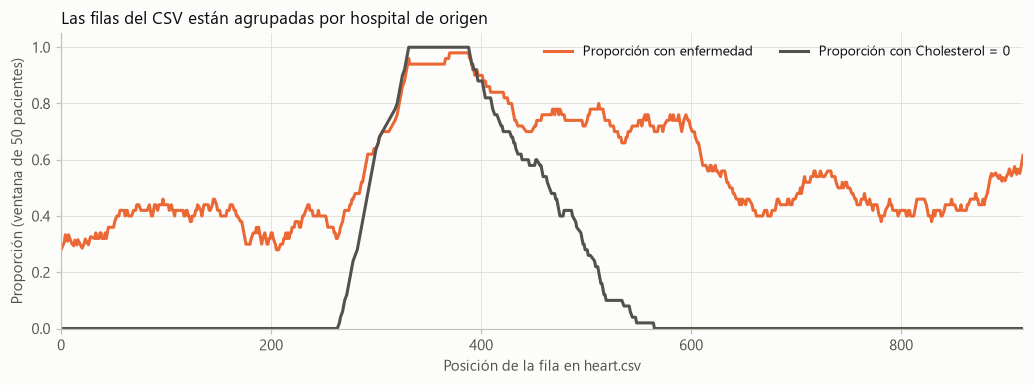

Pacientes de entrenamiento con Cholesterol = 0: 129, entre las posiciones 293 y 536 del archivo
% con enfermedad | Cholesterol = 0: 89.9%   | Cholesterol > 0: 47.9%


In [12]:
entrenamiento = X_train.assign(**{TARGET: y_train})
fig = plot_file_order(entrenamiento, TARGET)
plt.show()

colesterol_cero = X_train["Cholesterol"].eq(0)
print(f"Pacientes de entrenamiento con Cholesterol = 0: {colesterol_cero.sum()}, "
      f"entre las posiciones {X_train.index[colesterol_cero].min()} y {X_train.index[colesterol_cero].max()} del archivo")
print(f"% con enfermedad | Cholesterol = 0: {y_train[colesterol_cero].mean():.1%}"
      f"   | Cholesterol > 0: {y_train[~colesterol_cero].mean():.1%}")

**Lectura:** los 129 pacientes de entrenamiento con colesterol en 0 están todos en el tramo central del archivo (posiciones 293 a 536), que además tiene una proporción de enfermos mucho mayor que el resto. Coincide con los bloques de los hospitales de Suiza y Long Beach VA, donde no se registró el colesterol. En entrenamiento, entre quienes tienen colesterol 0 hay 89.9 % de enfermos, frente a 47.9 % en el resto.

Consecuencias para el diseño experimental:

1. La partición **aleatoria y estratificada** era necesaria (`train_test_split` baraja por defecto y `stratify=y` conserva la proporción de clases). Una partición secuencial habría dejado bloques enteros del archivo fuera del entrenamiento; el notebook 2 (sección 7.1) lo comprueba con Evidently.
2. La validación cruzada también debe **barajar** (`StratifiedKFold(shuffle=True)`): con `KFold` sin barajar, cada fold correspondería a hospitales distintos (sección 3.2).
3. Que falte el colesterol está asociado con la enfermedad **por el hospital de origen**, no por una razón clínica. Se retoma en la sección 5.1.

### 3.2 ¿Por qué barajar los folds de la validación cruzada?

Para comprobarlo sin tocar el conjunto de prueba, se reordena el **entrenamiento** según la posición original en el archivo y se compara `KFold` sin barajar contra `StratifiedKFold` con barajado (el esquema de `get_cv()`), con una regresión logística dentro del Pipeline.

In [13]:
X_ordenado, y_ordenado = X_train.sort_index(), y_train.sort_index()
modelo = build_pipeline(LogisticRegression(max_iter=5000))

esquemas = {
    "KFold sin barajar (archivo ordenado)": KFold(n_splits=5, shuffle=False),
    "StratifiedKFold con barajado (get_cv)": get_cv(),
}
filas = {}
for nombre, cv in esquemas.items():
    auc = cross_val_score(modelo, X_ordenado, y_ordenado, cv=cv, scoring="roc_auc")
    enfermos = [y_ordenado.iloc[val].mean() for _, val in cv.split(X_ordenado, y_ordenado)]
    fila = {f"fold {i + 1}": f"{a:.3f} ({p:.0%})" for i, (a, p) in enumerate(zip(auc, enfermos))}
    fila.update({"AUC medio": round(auc.mean(), 4), "d.e.": round(auc.std(), 4)})
    filas[nombre] = fila
display(pd.DataFrame(filas).T)
print("Formato: AUC del fold (% de enfermos en el fold de validación)")

,fold 1,fold 2,fold 3,fold 4,fold 5,AUC medio,d.e.
KFold sin barajar (archivo ordenado),0.951 (39%),0.942 (53%),0.900 (80%),0.855 (57%),0.876 (47%),0.9048,0.037
StratifiedKFold con barajado (get_cv),0.904 (55%),0.935 (55%),0.912 (55%),0.918 (56%),0.931 (55%),0.9201,0.0116


Formato: AUC del fold (% de enfermos en el fold de validación)


**Lectura:** sin barajar, cada fold toma un bloque contiguo del archivo: la proporción de enfermos en validación va de 39 % a 80 % y el AUC por fold va de 0.855 a 0.951, con una desviación estándar tres veces mayor (0.037 contra 0.012). Con `StratifiedKFold` barajado todos los folds tienen ~55 % de enfermos y la estimación es más estable (0.920 ± 0.012). Por eso todo el proyecto usa `get_cv()`, es decir, `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`.

## 4. Análisis exploratorio (solo con el conjunto de entrenamiento)

El análisis estadístico se hace con los 734 pacientes de entrenamiento. Mirar el conjunto de prueba para decidir el preprocesamiento o las variables sería otra forma, más sutil, de fuga: las decisiones quedarían ajustadas a esos pacientes y la evaluación final dejaría de ser independiente. En las columnas con faltantes ocultos los ceros se tratan como `NaN` para no distorsionar los estadísticos.

### 4.1 Variables numéricas

In [14]:
eda = X_train.copy()
eda[ZERO_AS_MISSING] = eda[ZERO_AS_MISSING].replace(0, np.nan)
continuas = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]


def resumen_numerico(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    atipicos = ((serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)).sum()
    return pd.Series({"media": serie.mean(), "mediana": serie.median(), "d.e.": serie.std(),
                      "mín": serie.min(), "máx": serie.max(), "IQR": iqr,
                      "asimetría": serie.skew(), "atípicos (regla IQR)": atipicos,
                      "faltantes": serie.isna().sum()})


display(eda[continuas].apply(resumen_numerico).T.round(2))

,media,mediana,d.e.,mín,máx,IQR,asimetría,atípicos (regla IQR),faltantes
Age,53.85,55.0,9.44,29.0,77.0,14.0,-0.21,0.0,0.0
RestingBP,132.87,130.0,18.08,92.0,200.0,21.0,0.63,20.0,0.0
Cholesterol,246.56,238.0,59.66,85.0,603.0,67.0,1.24,20.0,129.0
MaxHR,136.38,138.0,25.83,60.0,202.0,37.0,-0.19,2.0,0.0
Oldpeak,0.87,0.5,1.06,-2.6,5.6,1.5,0.95,13.0,0.0


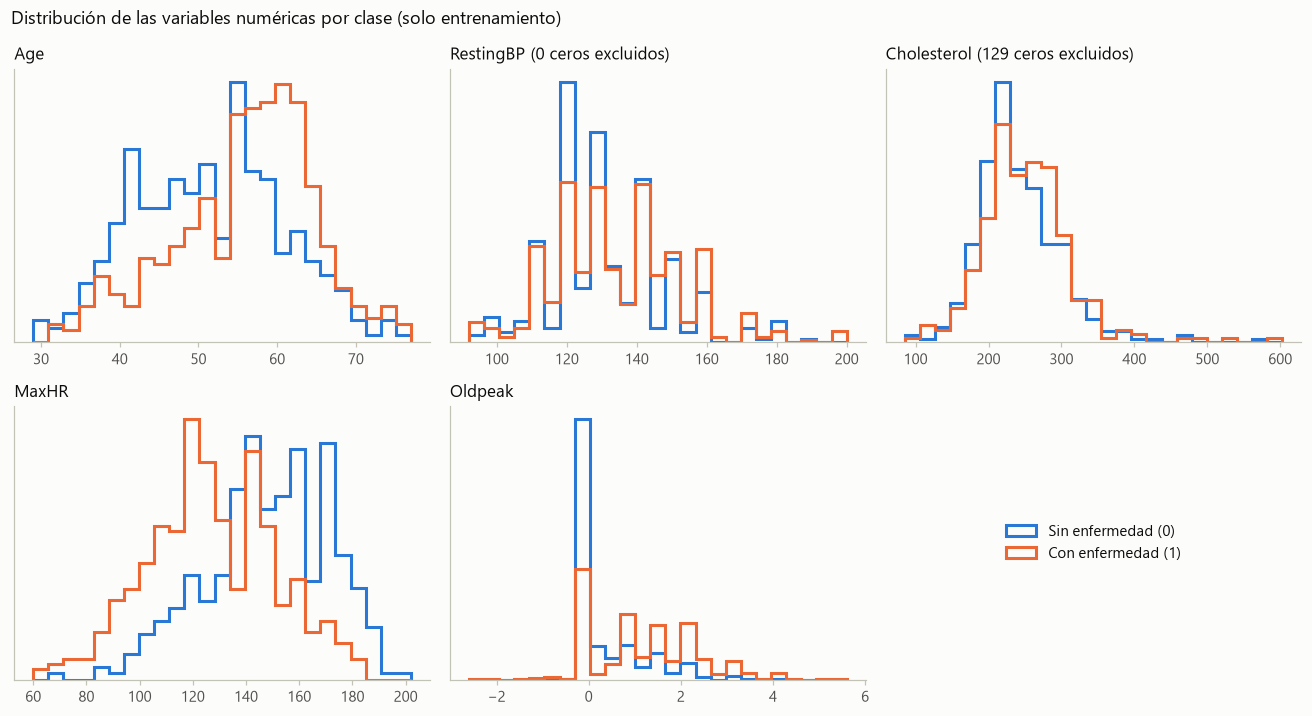

In [15]:
fig = plot_numeric_by_class(X_train, y_train, continuas, zero_as_missing=ZERO_AS_MISSING)
plt.show()

In [16]:
filas = []
for col in continuas:
    datos = pd.DataFrame({"x": eda[col], "y": y_train}).dropna()
    sanos, enfermos = datos.loc[datos.y == 0, "x"], datos.loc[datos.y == 1, "x"]
    _, p = stats.mannwhitneyu(sanos, enfermos, alternative="two-sided")
    r_pb, _ = stats.pointbiserialr(datos.y, datos.x)
    filas.append({"variable": col, "mediana sin enfermedad": sanos.median(),
                  "mediana con enfermedad": enfermos.median(),
                  "p-valor Mann-Whitney": p, "r punto-biserial": r_pb})
display(pd.DataFrame(filas).set_index("variable").round(4))

,mediana sin enfermedad,mediana con enfermedad,p-valor Mann-Whitney,r punto-biserial
variable,,,,
Age,52.0,57.0,0.0000,0.2447
RestingBP,130.0,132.0,0.0039,0.1021
Cholesterol,234.0,247.0,0.0134,0.0813
MaxHR,150.0,125.0,0.0000,-0.4072
Oldpeak,0.0,1.2,0.0000,0.3766


### 4.2 Variables categóricas

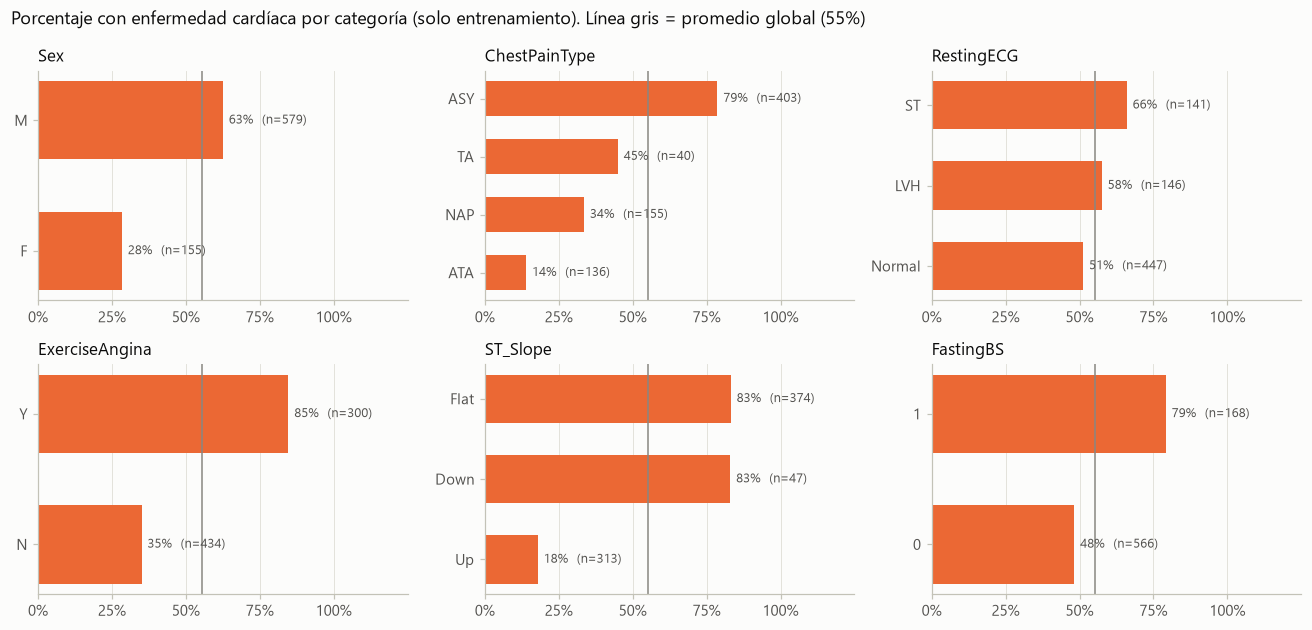

In [17]:
categoricas = CATEGORICAL_FEATURES + ["FastingBS"]
fig = plot_category_rates(X_train, y_train, categoricas)
plt.show()

In [18]:
def v_de_cramer(tabla):
    chi2 = stats.chi2_contingency(tabla, correction=False)[0]
    return np.sqrt(chi2 / (tabla.to_numpy().sum() * (min(tabla.shape) - 1)))


filas = []
for col in categoricas:
    tabla = pd.crosstab(X_train[col], y_train)
    chi2, p, gl, _ = stats.chi2_contingency(tabla)
    filas.append({"variable": col, "categorías": tabla.shape[0], "chi²": chi2, "gl": gl,
                  "p-valor": p, "V de Cramér": v_de_cramer(tabla)})
display(pd.DataFrame(filas).set_index("variable").sort_values("V de Cramér", ascending=False).round(4))

,categorías,chi²,gl,p-valor,V de Cramér
variable,,,,,
ST_Slope,3,309.1753,2,0.0000,0.6490
ChestPainType,4,214.3394,3,0.0000,0.5404
ExerciseAngina,2,174.8591,1,0.0000,0.4909
Sex,2,56.2632,1,0.0000,0.2802
FastingBS,2,48.9072,1,0.0000,0.2614
RestingECG,3,9.7690,2,0.0076,0.1154


### 4.3 Correlaciones y multicolinealidad

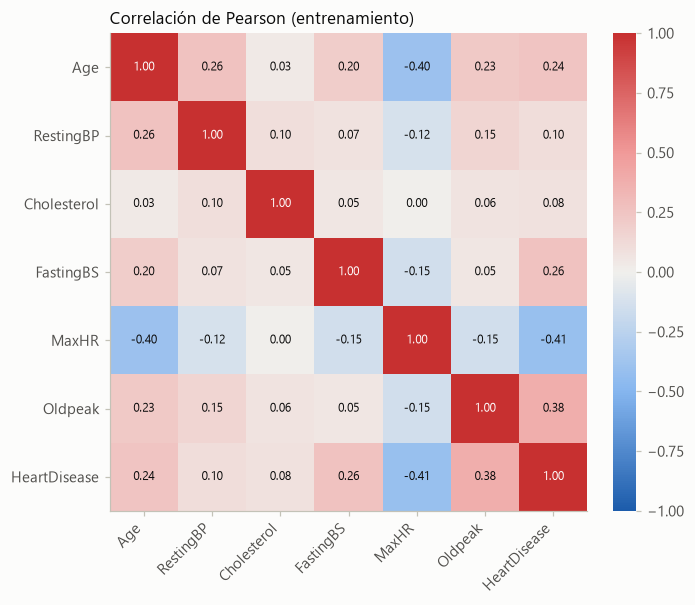

Pares de predictores con mayor |r|:
Age  MaxHR        0.398
     RestingBP    0.259
     Oldpeak      0.226


In [19]:
corr = correlation_with_target(X_train, y_train, NUMERIC_FEATURES, zero_as_missing=ZERO_AS_MISSING)
fig = plot_correlation(corr, "Correlación de Pearson (entrenamiento)")
plt.show()

predictores = corr.drop(index=TARGET, columns=TARGET)
triangulo = np.triu(np.ones(predictores.shape, dtype=bool), k=1)
pares = predictores.where(triangulo).stack().abs().sort_values(ascending=False)
print("Pares de predictores con mayor |r|:")
print(pares.head(3).round(3).to_string())

**Hallazgos del análisis exploratorio (entrenamiento):**

- **Variables numéricas:** los enfermos son mayores (mediana de 57 contra 52 años), alcanzan una frecuencia cardíaca máxima menor (`MaxHR`: 125 contra 150; r = −0.41) y tienen mayor depresión del ST (`Oldpeak`: 1.2 contra 0.0; r = 0.38). `RestingBP` y `Cholesterol` (cuando están medidos) difieren poco entre clases (r ≈ 0.10 y 0.08), aunque el test de Mann-Whitney sale significativo.
- **Atípicos:** la regla del IQR marca valores extremos (20 en `RestingBP`, 20 en `Cholesterol` con un máximo de 603 mg/dl, 13 en `Oldpeak`), pero son mediciones clínicamente posibles, así que se conservan. El `MinMaxScaler` es sensible a ellos; los modelos de árboles no.
- **Variables categóricas:** todas se asocian con la enfermedad (chi² con p < 0.01). Las más fuertes son `ST_Slope` (V de Cramér 0.65: 83 % de enfermos con pendiente plana o descendente contra 18 % con pendiente ascendente), `ChestPainType` (0.54: 79 % de enfermos con dolor asintomático `ASY`) y `ExerciseAngina` (0.49). `RestingECG` es la más débil (0.12).
- **Multicolinealidad:** la mayor correlación entre predictores es |r| = 0.40 (`Age` y `MaxHR`), lejos del umbral habitual de 0.7, así que no hay redundancias que obliguen a eliminar variables.
- **Faltantes:** en entrenamiento hay 129 colesteroles en 0 y ningún `RestingBP` en 0 (el único caso quedó en el conjunto de prueba). Aun así el imputador se aplica a ambas columnas, porque en producción pueden llegar pacientes sin esas mediciones.

## 5. Preprocesamiento dentro del Pipeline

El preprocesamiento se **define** una sola vez (`build_preprocessor`) y se **ajusta** siempre dentro del Pipeline, es decir, solo con los datos de entrenamiento de cada fold:

| Paso del Pipeline | Columnas | Transformación |
|---|---|---|
| `preprocessor` → `imputer` | `RestingBP`, `Cholesterol` | `SimpleImputer(missing_values=0, strategy="median")` |
| `preprocessor` → `numeric` | `Age`, `FastingBS`, `MaxHR`, `Oldpeak` | sin cambios en este paso |
| `preprocessor` → `categorical` | `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope` | `OneHotEncoder(handle_unknown="ignore")` |
| `scaler` | todas | `MinMaxScaler()` (como en el enunciado) |
| `clf` | — | el clasificador |

`handle_unknown="ignore"` evita que la API falle si en producción llega una categoría que no apareció en el entrenamiento (cap. 4.3).

In [20]:
build_pipeline(SVC(probability=True))

,steps,"[('preprocessor', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('imputer', ...), ('numeric', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
pre = build_preprocessor().fit(X_train)
print(f"{len(pre.get_feature_names_out())} columnas después del preprocesamiento:")
print(list(pre.get_feature_names_out()))

mediana_train = pre.named_transformers_["imputer"].statistics_
mediana_todo = build_preprocessor().fit(df[FEATURES]).named_transformers_["imputer"].statistics_
display(pd.DataFrame({"mediana aprendida solo con entrenamiento (correcto)": mediana_train,
                      "mediana aprendida con los 918 pacientes (fuga)": mediana_todo},
                     index=ZERO_AS_MISSING))

20 columnas después del preprocesamiento:
['imputer__RestingBP', 'imputer__Cholesterol', 'numeric__Age', 'numeric__FastingBS', 'numeric__MaxHR', 'numeric__Oldpeak', 'categorical__Sex_F', 'categorical__Sex_M', 'categorical__ChestPainType_ASY', 'categorical__ChestPainType_ATA', 'categorical__ChestPainType_NAP', 'categorical__ChestPainType_TA', 'categorical__RestingECG_LVH', 'categorical__RestingECG_Normal', 'categorical__RestingECG_ST', 'categorical__ExerciseAngina_N', 'categorical__ExerciseAngina_Y', 'categorical__ST_Slope_Down', 'categorical__ST_Slope_Flat', 'categorical__ST_Slope_Up']


,mediana aprendida solo con entrenamiento (correcto),mediana aprendida con los 918 pacientes (fuga)
RestingBP,130.0,130.0
Cholesterol,238.0,237.0


### 5.1 ¿Conviene agregar un indicador de "colesterol no medido"?

`SimpleImputer(add_indicator=True)` agrega una columna 0/1 que marca los valores imputados. Se compara con validación cruzada (solo entrenamiento) en un modelo lineal y en uno de árboles:

In [22]:
falta = X_train["Cholesterol"].eq(0)
print(f"% con enfermedad (entrenamiento) | colesterol no medido: {y_train[falta].mean():.1%}"
      f"  | medido: {y_train[~falta].mean():.1%}")

filas = []
for nombre, modelo in {"Regresión logística": LogisticRegression(max_iter=5000),
                       "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)}.items():
    for indicador in (False, True):
        auc = cross_val_score(build_pipeline(modelo, add_indicator=indicador), X_train, y_train,
                              cv=get_cv(), scoring="roc_auc")
        filas.append({"modelo": nombre, "add_indicator": indicador, "CV AUC": auc.mean(), "d.e.": auc.std()})
display(pd.DataFrame(filas).set_index(["modelo", "add_indicator"]).round(4))

% con enfermedad (entrenamiento) | colesterol no medido: 89.9%  | medido: 47.9%


CV AUC    d.e.
modelo              add_indicator                
Regresión logística False          0.9227  0.0348
                    True           0.9287  0.0377
Random Forest       False          0.9259  0.0255
                    True           0.9285  0.0272

**Resultado:** el indicador sube muy poco el AUC de validación cruzada (+0.006 en regresión logística y +0.003 en Random Forest, bastante menos que la desviación entre folds, ≈ 0.03). Y lo que aprovecha es un **artefacto de cómo se armó el dataset**: el colesterol falta casi solo en los pacientes de Suiza y Long Beach VA, que en entrenamiento tienen 89.9 % de enfermos. Con el indicador el modelo aprendería que *"no tener el colesterol medido = riesgo alto"*, algo que no se sostiene en otro hospital.

**Decisión:** no se agrega el indicador (`add_indicator=False`). Se renuncia a una ganancia marginal a cambio de un modelo que no dependa de la forma en que se recolectaron los datos. Limitación a tener en cuenta: aun sin indicador, los valores imputados (todos iguales a la mediana) siguen identificando en parte a esos pacientes.

## 6. Demostración de *data leakage*

### 6.1 Ejemplo del enunciado

Se ejecuta el código del enunciado con solo dos adaptaciones, necesarias para este dataset:

1. La variable objetivo se llama `HeartDisease` (el ejemplo usa `target`, el nombre de la columna en el dataset de UCI).
2. El CSV de Kaggle tiene 5 columnas de texto y `MinMaxScaler` solo acepta números, así que se codifican con `pd.get_dummies`.

Todo lo demás es literal: se agrega `leaky_feature = y + ruido` (una variable construida con la respuesta) y se compara un flujo que escala antes de partir contra uno que usa `Pipeline`. Las variables del flujo correcto se renombraron (`X_train_e`, …) solo para no sobrescribir la partición principal del notebook.

> El ejemplo usa **su propia partición** (`train_test_split` sin `stratify`), distinta de la del proyecto. Sus resultados solo ilustran el efecto de la fuga y no se comparan con el ranking de la sección 8; el resto del notebook usa la partición de `split_data()`.

In [23]:
# ---- Código del enunciado (adaptado: HeartDisease y variables dummy) ----
X = df.drop(TARGET, axis=1)
y = df[TARGET]
X = pd.get_dummies(X, columns=CATEGORICAL_FEATURES, dtype=float)

# Variable artificial que introduce fuga
np.random.seed(0)
X["leaky_feature"] = y + np.random.normal(0, 0.01, size=len(y))

# Ejemplo con fuga de datos (data leakage)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

grid_l = GridSearchCV(SVC(probability=True), param_grid={"C": [0.1, 1, 10], "gamma": [0.01, 0.1]},
                      cv=5, scoring="roc_auc")
grid_l.fit(X_train_l, y_train_l)
auc_l = roc_auc_score(y_test_l, grid_l.predict_proba(X_test_l)[:, 1])

# Flujo correcto (sin fuga)
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X, y, test_size=0.2, random_state=42)

pipe = Pipeline([("scaler", MinMaxScaler()), ("svc", SVC(probability=True))])
param_grid = {"svc__C": [0.1, 1, 10], "svc__gamma": [0.01, 0.1]}
grid = GridSearchCV(pipe, param_grid, cv=5, scoring="roc_auc")
grid.fit(X_train_e, y_train_e)
auc = roc_auc_score(y_test_e, grid.predict_proba(X_test_e)[:, 1])

print(f"AUC con fuga: {auc_l:.3f}")
print(f"AUC sin fuga: {auc:.3f}")

AUC con fuga: 1.000
AUC sin fuga: 1.000


**¿Por qué el flujo "sin fuga" también da un AUC de 1?** Porque `leaky_feature` sigue dentro de `X` en ambos flujos. El `Pipeline` evita la fuga de **preprocesamiento** (el escalador ya no ve el conjunto de prueba), pero no puede saber que una **columna** se construyó con la respuesta. Esa fuga por la variable objetivo (*target leakage*) solo se corrige quitando la columna: en producción no existiría, porque el diagnóstico es justamente lo que se quiere predecir.

Flujo correcto corregido (misma partición del ejemplo, sin `leaky_feature`):

In [24]:
X_train_c = X_train_e.drop(columns="leaky_feature")
X_test_c = X_test_e.drop(columns="leaky_feature")
grid_c = GridSearchCV(pipe, param_grid, cv=5, scoring="roc_auc").fit(X_train_c, y_train_e)
auc_c = roc_auc_score(y_test_e, grid_c.predict_proba(X_test_c)[:, 1])
print(f"AUC sin fuga (Pipeline y sin leaky_feature): {auc_c:.3f}")
print(f"Huella de la partición del ejemplo: {split_fingerprint(X_test_e)} "
      f"(la del proyecto es {split_fingerprint(X_test)})")

AUC sin fuga (Pipeline y sin leaky_feature): 0.924
Huella de la partición del ejemplo: 61d768314e45 (la del proyecto es 6f866816e8c7)


### 6.2 Aislando cada tipo de fuga (diseño 2 × 2)

Para separar los dos efectos se usa la partición estratificada del proyecto y el preprocesamiento completo (imputación + one-hot + escalado) con un SVC y su `GridSearchCV`:

- **Factor A, dónde se ajusta el preprocesamiento:** con los 918 pacientes antes de partir (fuga) o dentro del Pipeline (correcto).
- **Factor B, `leaky_feature`:** presente o ausente.

In [25]:
rng = np.random.RandomState(0)
leaky_todos = df[TARGET] + rng.normal(0, 0.01, size=len(df))
grilla_svc = {"clf__C": [0.01, 0.1, 1, 10, 100], "clf__gamma": [0.001, 0.01, 0.1, 1]}


def experimento_fuga(preprocesar_antes, con_leaky):
    Xtr, Xte = X_train.copy(), X_test.copy()
    if con_leaky:
        Xtr["leaky_feature"] = leaky_todos.loc[Xtr.index]
        Xte["leaky_feature"] = leaky_todos.loc[Xte.index]
    svc = SVC(probability=True, random_state=RANDOM_STATE)
    if preprocesar_antes:
        # INCORRECTO: medianas, categorías y mín/máx se aprenden con los 918 pacientes
        prep = Pipeline([("preprocessor", build_preprocessor().set_params(remainder="passthrough")),
                         ("scaler", MinMaxScaler())])
        todos = pd.concat([Xtr, Xte])
        Z = pd.DataFrame(prep.fit_transform(todos), index=todos.index)
        Xtr, Xte = Z.loc[Xtr.index], Z.loc[Xte.index]
        modelo = Pipeline([("clf", svc)])
    else:
        # CORRECTO: todo el preprocesamiento se ajusta dentro de cada fold
        modelo = build_pipeline(svc)
        modelo.set_params(preprocessor__remainder="passthrough")
    busqueda = GridSearchCV(modelo, grilla_svc, cv=get_cv(), scoring="roc_auc", n_jobs=-1).fit(Xtr, y_train)
    return {"CV AUC": busqueda.best_score_,
            "AUC prueba": roc_auc_score(y_test, busqueda.predict_proba(Xte)[:, 1]),
            "mejores parámetros": busqueda.best_params_}


filas = []
for con_leaky in (False, True):
    for antes in (True, False):
        fila = {"leaky_feature": "sí" if con_leaky else "no",
                "preprocesamiento": "antes de partir (fuga)" if antes else "dentro del Pipeline"}
        fila.update(experimento_fuga(antes, con_leaky))
        filas.append(fila)
resultados_fuga = pd.DataFrame(filas).set_index(["leaky_feature", "preprocesamiento"])
display(resultados_fuga.round(4))

CV AUC  AUC prueba  \
leaky_feature preprocesamiento                             
no            antes de partir (fuga)  0.9192      0.9317   
              dentro del Pipeline     0.9194      0.9143   
sí            antes de partir (fuga)  1.0000      1.0000   
              dentro del Pipeline     1.0000      1.0000   

                                                       mejores parámetros  
leaky_feature preprocesamiento                                             
no            antes de partir (fuga)  {'clf__C': 100, 'clf__gamma': 0.01}  
              dentro del Pipeline      {'clf__C': 0.1, 'clf__gamma': 0.1}  
sí            antes de partir (fuga)   {'clf__C': 0.1, 'clf__gamma': 0.1}  
              dentro del Pipeline      {'clf__C': 0.1, 'clf__gamma': 0.1}

**Lectura del diseño 2 × 2:**

- **Fuga por preprocesamiento (sin `leaky_feature`):** el AUC de validación cruzada casi no cambia (0.9192 contra 0.9194), tal como anticipa el libro para el escalado: aquí las medianas y los mínimos/máximos aprendidos con los 918 pacientes son casi iguales a los del entrenamiento (sección 5). Aun así, cambió los hiperparámetros elegidos (C = 100 y γ = 0.01 contra C = 0.1 y γ = 0.1). La diferencia en prueba (0.932 contra 0.914) está dentro del ruido de 184 pacientes (un IC bootstrap de AUC en prueba mide unos ±0.04), pero el problema de fondo no es el número: en el flujo con fuga el conjunto de prueba participó en el ajuste, así que su AUC **ya no es una estimación válida** del desempeño con pacientes nuevos.
- **Fuga por la variable objetivo (`leaky_feature`):** el AUC es 1.000 en ambos casos, con o sin Pipeline. Ningún Pipeline la detecta; la única corrección es eliminar la variable.

### 6.3 Fuga en la selección de variables (caps. 10.3 y 10.4)

El libro advierte que el efecto de escalar con el conjunto de prueba es pequeño, pero que usarlo para **seleccionar variables** distorsiona mucho los resultados. Se replica con las etiquetas reales del proyecto y 10 000 variables de **ruido puro**: como no tienen relación alguna con `HeartDisease`, el AUC honesto es 0.5. Se eligen las 25 "mejores" con `SelectKBest` antes de partir (incorrecto) o dentro del Pipeline (correcto).

In [26]:
rng = np.random.RandomState(RANDOM_STATE)
ruido = pd.DataFrame(rng.standard_normal((len(df), 10_000)), index=df.index)
R_train, R_test = ruido.loc[X_train.index], ruido.loc[X_test.index]

# INCORRECTO: SelectKBest ve las etiquetas de los 918 pacientes (incluidos los de prueba)
selector = SelectKBest(f_classif, k=25).fit(ruido, df[TARGET])
logit = LogisticRegression(max_iter=5000)
cv_mal = cross_val_score(logit, selector.transform(R_train), y_train, cv=get_cv(), scoring="roc_auc").mean()
logit.fit(selector.transform(R_train), y_train)
test_mal = roc_auc_score(y_test, logit.predict_proba(selector.transform(R_test))[:, 1])

# CORRECTO: la selección es un paso más del Pipeline
pipe_sel = make_pipeline(SelectKBest(f_classif, k=25), LogisticRegression(max_iter=5000))
cv_bien = cross_val_score(pipe_sel, R_train, y_train, cv=get_cv(), scoring="roc_auc").mean()
test_bien = roc_auc_score(y_test, pipe_sel.fit(R_train, y_train).predict_proba(R_test)[:, 1])

display(pd.DataFrame({"CV AUC": [cv_mal, cv_bien], "AUC prueba": [test_mal, test_bien]},
                     index=["selección antes de partir (fuga)", "selección dentro del Pipeline"]).round(3))

,CV AUC,AUC prueba
selección antes de partir (fuga),0.738,0.759
selección dentro del Pipeline,0.491,0.513


**Lectura:** con variables de ruido puro, seleccionar antes de partir da un AUC de 0.74 en validación cruzada y 0.76 en prueba, cuando lo honesto es ~0.5, que es justo lo que se obtiene con la selección dentro del Pipeline (0.49 y 0.51). El conjunto de prueba no sirve de alarma: como la selección ya "vio" sus etiquetas, también da un resultado inflado.

**Resumen de lo observado sobre fugas y particiones**

| Problema | Qué ocurre | Efecto en este dataset | Cómo se evita |
|---|---|---|---|
| Preprocesamiento antes de partir (imputación, escalado) | medianas y mínimos/máximos se calculan con pacientes de prueba | pequeño en el AUC (0.919 en ambos casos), pero invalida la evaluación y cambió los hiperparámetros | ajustar el preprocesamiento dentro del `Pipeline` |
| Variable construida con la respuesta (`leaky_feature`) | el modelo "lee" la respuesta | AUC = 1.000 aun usando Pipeline | quitar variables que no existirán al momento de predecir |
| Selección de variables antes de partir | se eligen variables usando las etiquetas de prueba | AUC de 0.74 a 0.76 con ruido puro (lo real es 0.5) | incluir la selección como un paso del `Pipeline` |
| Folds sin barajar sobre un archivo ordenado (problema de partición) | cada fold corresponde a hospitales distintos | AUC por fold de 0.855 a 0.951 | `StratifiedKFold(shuffle=True)` |

## 7. Comparación de modelos sin fuga (Pipeline + GridSearchCV)

El enunciado pide *implementar todos los modelos vistos hasta esta sección* (al menos tres además de SVC). Se incluyen los 13 clasificadores que presenta el libro hasta el capítulo 10: k-NN (cap. 2); regresión logística y LinearSVC (cap. 3); Naive Bayes gaussiano y Bernoulli (cap. 4); árbol de decisión, *bagging*, Random Forest, AdaBoost, Gradient Boosting y XGBoost (cap. 5); SVC (cap. 6) y el perceptrón multicapa que usa el ejemplo del cap. 9.9. Se agrega un `DummyClassifier` como línea base (cap. 9.9): predice siempre la proporción de clases y marca el piso de AUC = 0.5.

No se incluyen `MultinomialNB`, que el cap. 4 reserva para conteos (por ejemplo, frecuencias de palabras), ni `SGDClassifier`, que el cap. 3 solo menciona para conjuntos de datos muy grandes.

**Protocolo, idéntico para todos los modelos:**

- Pipeline `preprocessor → MinMaxScaler → clf`, construido por la función reutilizable `train_pipeline` (sección 1.2), versión generalizada de la que sugiere el enunciado.
- `GridSearchCV` solo con el entrenamiento, `StratifiedKFold(5, shuffle=True, random_state=42)`, métricas `roc_auc` y `accuracy`; el mejor candidato se elige por AUC (`refit="roc_auc"`).
- Todos los modelos usan **los mismos 5 folds**, así que sus AUC de validación cruzada son comparables.
- El conjunto de prueba se evalúa una vez por modelo, solo para reportar.

In [27]:
catalogo = get_model_catalog()
display(pd.DataFrame([
    {"modelo": nombre,
     "capítulo del curso": spec["capitulo"],
     "hiperparámetros explorados": ", ".join(k.replace("clf__", "") for k in spec["param_grid"]) or "—",
     "combinaciones": int(np.prod([len(v) for v in spec["param_grid"].values()]))}
    for nombre, spec in catalogo.items()
]).set_index("modelo"))

,capítulo del curso,hiperparámetros explorados,combinaciones
modelo,,,
k-NN,2. k-NN,"n_neighbors, weights, p",36
Regresión logística,3. Modelos lineales,C,6
LinearSVC,3. Modelos lineales,C,5
Naive Bayes gaussiano,4. Clasificador bayesiano,var_smoothing,11
Naive Bayes Bernoulli,4. Clasificador bayesiano,"alpha, binarize",15
Árbol de decisión,5. Árboles,"max_depth, min_samples_leaf, criterion",84
Bagging (árboles),5. Bagging,"max_samples, max_features",25
Random Forest,5. Random Forest,"max_depth, max_features, min_samples_leaf",24
AdaBoost,5. Boosting (AdaBoost),"n_estimators, learning_rate",20


In [28]:
resultados, busquedas = compare_models(catalogo, X_train, y_train, X_test, y_test)

k-NN                     CV AUC = 0.923 (± 0.032) |   2.5 s


Regresión logística      CV AUC = 0.923 (± 0.035) |   0.3 s


LinearSVC                CV AUC = 0.922 (± 0.035) |   0.2 s


Naive Bayes gaussiano    CV AUC = 0.918 (± 0.037) |   0.4 s


Naive Bayes Bernoulli    CV AUC = 0.919 (± 0.036) |   0.6 s


Árbol de decisión        CV AUC = 0.912 (± 0.024) |   2.8 s


Bagging (árboles)        CV AUC = 0.930 (± 0.030) |  13.2 s


Random Forest            CV AUC = 0.931 (± 0.025) |  13.7 s


AdaBoost                 CV AUC = 0.924 (± 0.037) |   9.0 s


Gradient Boosting        CV AUC = 0.931 (± 0.028) | 102.8 s


XGBoost                  CV AUC = 0.933 (± 0.028) |  43.9 s


SVC (RBF)                CV AUC = 0.919 (± 0.033) |   3.0 s


MLP                      CV AUC = 0.924 (± 0.033) |   9.3 s
Dummy (línea base)       CV AUC = 0.500 (± 0.000) |   0.1 s


In [29]:
avisos = resultados.loc[resultados["avisos_borde"] != "", "avisos_borde"]
if avisos.empty:
    print("Ningún hiperparámetro óptimo quedó en el borde de su grilla.")
else:
    print("Hiperparámetros cuyo óptimo quedó en el borde de la grilla:")
    display(avisos.to_frame())

Ningún hiperparámetro óptimo quedó en el borde de su grilla.


`grid_boundary_warnings()` revisa todos los hiperparámetros numéricos con al menos dos valores. Solo omite `p` de k-NN, que elige la métrica de distancia y no es ordinal, y el máximo natural 1.0 de las fracciones (`subsample`, `max_samples`, `max_features`).

Durante el desarrollo varios óptimos quedaron en un extremo de su grilla, señal de que el verdadero óptimo podía estar fuera. Por ejemplo: `n_neighbors` = 31 y luego 71 en k-NN, `var_smoothing` = 0.1 en Naive Bayes gaussiano, `alpha` = 10 en Naive Bayes Bernoulli, `C` = 0.1 en SVC, `max_depth` = 3 y `subsample` = 0.6 en Gradient Boosting, `subsample` = 0.6 en XGBoost y `max_samples`/`max_features` = 0.25 en *bagging*. Las grillas de `get_model_catalog()` se ampliaron hasta que ningún óptimo quedó en un extremo.

## 8. Ranking comparativo

El ranking **se ordena por el AUC de validación cruzada**, que se calcula solo con el entrenamiento. Las columnas de prueba se muestran como estimación final, pero no se usan para ordenar ni para elegir: escoger el modelo al que mejor le va en prueba sería ajustar la decisión al conjunto de prueba (cap. 9.2.2, *el peligro de sobreajustar los parámetros y el conjunto de validación*).

In [30]:
ranking = rank_models(resultados)
columnas = {"ranking": "ranking", "capitulo": "capítulo",
            "cv_auc": "AUC CV", "cv_auc_std": "d.e. AUC CV",
            "cv_accuracy": "Accuracy CV", "cv_accuracy_std": "d.e. Accuracy CV",
            "test_auc": "AUC prueba", "test_accuracy": "Accuracy prueba",
            "test_recall": "Sensibilidad prueba", "test_specificity": "Especificidad prueba",
            "gap_auc": "Brecha train-val (AUC)"}
display(ranking[list(columnas)].rename(columns=columnas).round(4))

,ranking,capítulo,AUC CV,d.e. AUC CV,Accuracy CV,d.e. Accuracy CV,AUC prueba,Accuracy prueba,Sensibilidad prueba,Especificidad prueba,Brecha train-val (AUC)
modelo,,,,,,,,,,,
XGBoost,1,5. XGBoost,0.9332,0.0276,0.8597,0.0304,0.9295,0.8859,0.9020,0.8659,0.0438
Random Forest,2,5. Random Forest,0.9313,0.0251,0.8529,0.0355,0.9281,0.8967,0.9314,0.8537,0.0522
Gradient Boosting,3,5. Boosting,0.9308,0.0281,0.8556,0.0237,0.9284,0.8804,0.9020,0.8537,0.0397
Bagging (árboles),4,5. Bagging,0.9297,0.0296,0.8624,0.0352,0.9303,0.9076,0.9314,0.8780,0.0492
AdaBoost,5,5. Boosting (AdaBoost),0.9243,0.0374,0.8638,0.0271,0.9270,0.8750,0.8824,0.8659,0.0106
MLP,6,9. Evaluación (ej. DeLong),0.9235,0.0328,0.8501,0.0265,0.9302,0.9022,0.9412,0.8537,0.0089
k-NN,7,2. k-NN,0.9230,0.0316,0.8542,0.0270,0.9375,0.8967,0.9216,0.8659,0.0770
Regresión logística,8,3. Modelos lineales,0.9227,0.0348,0.8529,0.0287,0.9309,0.8967,0.9314,0.8537,0.0063
LinearSVC,9,3. Modelos lineales,0.9223,0.0353,0.8474,0.0328,0.9293,0.8804,0.9118,0.8415,0.0062


In [31]:
display(ranking[["mejores_parametros"]].rename(columns={"mejores_parametros": "mejores hiperparámetros"}))

,mejores hiperparámetros
modelo,
XGBoost,"{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 600, 'subsample': 0.6}"
Random Forest,"{'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 3}"
Gradient Boosting,"{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.6}"
Bagging (árboles),"{'max_features': 0.25, 'max_samples': 0.25}"
AdaBoost,"{'learning_rate': 0.1, 'n_estimators': 200}"
MLP,"{'alpha': 1.0, 'hidden_layer_sizes': (16,)}"
k-NN,"{'n_neighbors': 71, 'p': 2, 'weights': 'distance'}"
Regresión logística,{'C': 1}
LinearSVC,{'C': 0.1}


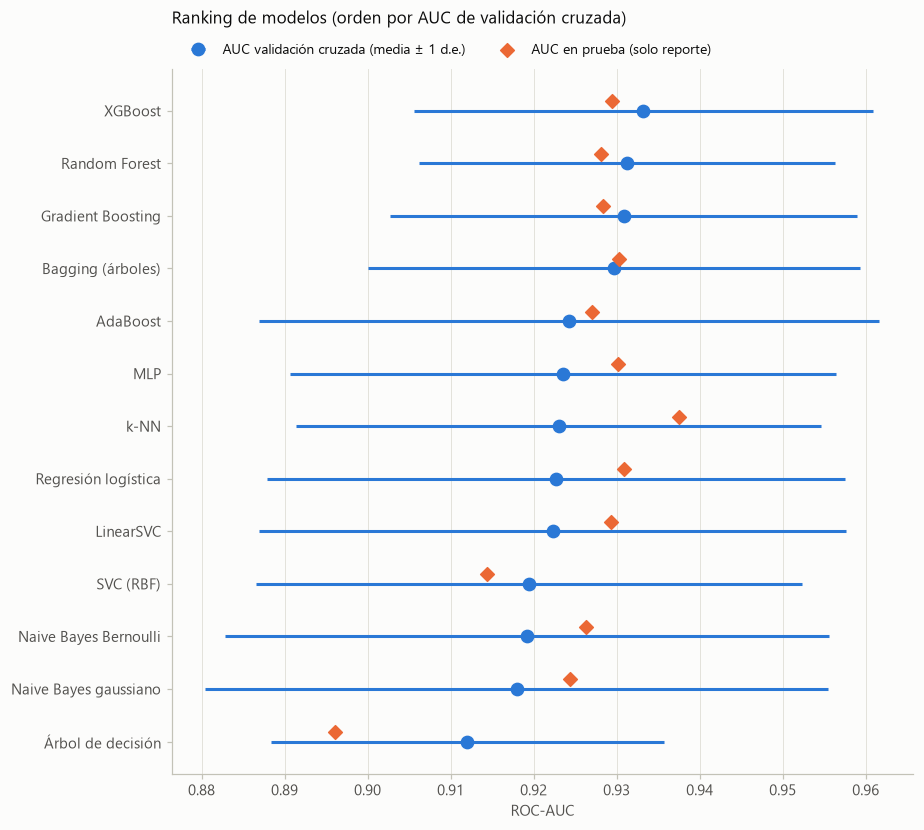

In [32]:
fig = plot_model_ranking(ranking, exclude=["Dummy (línea base)"])
plt.show()

**Lectura del ranking:**

- Los ensambles de árboles encabezan la validación cruzada y están **prácticamente empatados**: XGBoost 0.9332, Random Forest 0.9313, Gradient Boosting 0.9308 y *bagging* 0.9297. La mayor diferencia entre ellos (0.0035) es unas 8 veces menor que la desviación entre folds (≈ 0.028).
- Siguen AdaBoost, MLP, k-NN, regresión logística y LinearSVC (0.922 a 0.924), y después SVC con kernel RBF, los dos Naive Bayes y el árbol de decisión individual (0.912). Todos superan con holgura a la línea base (0.500). En *accuracy* de validación cruzada quedan entre 0.838 (árbol de decisión) y 0.864 (AdaBoost).
- **El orden en prueba no coincide con el de validación cruzada:** k-NN tiene el mejor AUC en prueba (0.9375) aunque es séptimo en CV. Con 184 pacientes esas diferencias son ruido (sección 8.1); elegir por el resultado en prueba habría sido ajustar la elección a esos 184 pacientes.
- **Brecha entrenamiento-validación:** es casi nula en los modelos lineales, SVC, los Naive Bayes, MLP y AdaBoost (≤ 0.011) y mayor en los ensambles de árboles y k-NN (0.04 a 0.08). En Random Forest, *bagging* y k-NN con `weights="distance"` el AUC de entrenamiento es cercano a 1 por construcción (cada paciente de entrenamiento "se ve a sí mismo"); lo importante es que su AUC de validación sigue entre los más altos. Se analiza con la curva de aprendizaje en el notebook 2 (sección 4.2).

### 8.1 ¿Las diferencias son significativas? Test de DeLong (cap. 9.9)

Con 184 pacientes de prueba, diferencias de AUC de centésimas pueden deberse al azar. Se compara el primer modelo del ranking contra cada uno de los demás con el test de DeLong **pareado** validado en la sección 1.3. La magnitud se clasifica con la leyenda del libro: < 0.01 trivial, 0.01–0.03 pequeña, 0.03–0.05 moderada y > 0.05 importante.

In [33]:
mejor = ranking.index[0]
puntajes = {nombre: positive_scores(busquedas[nombre], X_test) for nombre in ranking.index}
display(delong_vs_reference(y_test, puntajes, mejor).round(4))

bajo, alto = bootstrap_auc_ci(y_test, puntajes[mejor])
print(f"{mejor}: AUC en prueba = {roc_auc_score(y_test, puntajes[mejor]):.3f} "
      f"(IC bootstrap 95 %: {bajo:.3f} a {alto:.3f})")

,delta_auc,magnitud,z,p_value,significativa,interpretacion
comparacion,,,,,,
XGBoost vs Random Forest,0.0013,trivial,0.2359,0.8135,No,Diferencia trivial y no significativa
XGBoost vs Gradient Boosting,0.0011,trivial,0.2653,0.7908,No,Diferencia trivial y no significativa
XGBoost vs Bagging (árboles),-0.0008,trivial,-0.1134,0.9097,No,Diferencia trivial y no significativa
XGBoost vs AdaBoost,0.0025,trivial,0.3030,0.7619,No,Diferencia trivial y no significativa
XGBoost vs MLP,-0.0007,trivial,-0.0911,0.9274,No,Diferencia trivial y no significativa
XGBoost vs k-NN,-0.0080,trivial,-0.9959,0.3193,No,Diferencia trivial y no significativa
XGBoost vs Regresión logística,-0.0014,trivial,-0.1712,0.8640,No,Diferencia trivial y no significativa
XGBoost vs LinearSVC,0.0001,trivial,0.0143,0.9886,No,Diferencia trivial y no significativa
XGBoost vs SVC (RBF),0.0151,pequeña,1.2645,0.2060,No,Diferencia trivial y no significativa


XGBoost: AUC en prueba = 0.929 (IC bootstrap 95 %: 0.889 a 0.963)


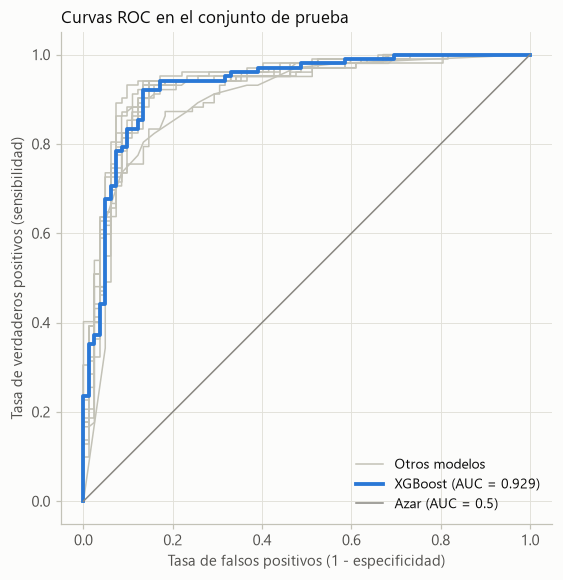

In [34]:
fig, ax = plt.subplots(figsize=(6.2, 5.8))
plot_roc_emphasis(y_test, {k: v for k, v in puntajes.items() if k != "Dummy (línea base)"}, mejor, ax=ax)
ax.set_title("Curvas ROC en el conjunto de prueba", loc="left")
plt.show()

**Lectura:** en el conjunto de prueba ninguna diferencia entre XGBoost y los otros once modelos competitivos es estadísticamente significativa (todos los p-valores son mayores que 0.2); casi todas son triviales (|ΔAUC| < 0.01) y la mayor es la de SVC (0.015, pequeña). Solo el árbol de decisión individual (ΔAUC = 0.033, moderada, p = 0.0008) y la línea base son significativamente peores, y lo siguen siendo con la corrección de Bonferroni por hacer 13 comparaciones (umbral 0.05/13 ≈ 0.004). El intervalo bootstrap del AUC de XGBoost en prueba (0.889 a 0.963) contiene los AUC de esos once modelos, y sus curvas ROC se superponen casi por completo.

## 9. Conclusiones de la etapa 1

1. **Datos:** 918 pacientes sin `NaN` ni duplicados, pero con faltantes ocultos (172 `Cholesterol` = 0 y un `RestingBP` = 0) que se imputan con la mediana **dentro del Pipeline**. El archivo está ordenado por hospital y la falta de colesterol se asocia con la enfermedad por el origen de los datos; por eso no se agrega un indicador de faltante.
2. **Particiones:** partición estratificada 80/20 hecha antes de cualquier transformación (734 y 184 pacientes, con 55.3 % y 55.4 % de enfermos y ningún paciente compartido) y validación cruzada estratificada **con barajado** (sin barajar, el AUC por fold oscila entre 0.855 y 0.951). La huella de la partición (`6f866816e8c7`) permite verificar que el notebook 2, las pruebas y el monitoreo usan exactamente los mismos conjuntos; la única excepción es la reproducción literal del ejemplo del enunciado (sección 6.1), que usa su propia partición. El conjunto de prueba solo se usó para reportar métricas, nunca para decidir.
3. ***Data leakage*:** el ejemplo del enunciado da AUC = 1.000 en los dos flujos porque `leaky_feature` sigue en el flujo "correcto"; al quitarla, el AUC es 0.924 (con la partición del propio ejemplo). El Pipeline evita la fuga de preprocesamiento (de efecto pequeño con imputación y escalado), pero no la fuga por variables construidas con la respuesta. La fuga más dañina en la práctica es seleccionar variables fuera de la validación cruzada (AUC de 0.74 contra 0.5 real).
4. **Modelos:** se implementaron los 13 clasificadores del curso más la línea base, todos con `Pipeline` + `GridSearchCV`, los mismos folds y sin óptimos en el borde de sus grillas. Los ensambles de árboles lideran el ranking (AUC de CV de 0.930 a 0.933), pero sus diferencias con los demás modelos competitivos no son significativas en prueba (DeLong).
5. **Decisión para la etapa 2:** XGBoost, Random Forest, Gradient Boosting y *bagging* están empatados, pero XGBoost no conviene para el despliegue: la versión usada (3.4.1) ya no es compatible con Python 3.10 (el de la imagen Docker del enunciado) y en Linux agrega unos 450 MB a la imagen (el paquete más la librería NCCL de NVIDIA). Por eso, en el notebook 2, el modelo final se elige entre los candidatos que solo dependen de scikit-learn y ofrecen `predict_proba` (11 familias), de nuevo con `GridSearchCV` y sin mirar el conjunto de prueba.